In [1]:
print("hi")

hi


In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

In [5]:
llm = ChatGroq(model_name="deepseek-r1-distill-llama-70b")

In [6]:
llm.invoke("what is the capital of australia")

AIMessage(content="<think>\nOkay, so I need to figure out what the capital of Australia is. I'm not entirely sure, but I think it's a city that's not as famous as Sydney or Melbourne. Let me start by recalling what I know about Australia. I know it's a country with several major cities, but the capital is different from the largest city. In the United States, for example, the capital is Washington D.C., which isn't the biggest city. Maybe Australia has a similar setup.\n\nI remember hearing that Australia's capital isn't Sydney or Melbourne. Sydney is the biggest city and a major tourist spot with the Opera House and Harbour Bridge. Melbourne is known for its cultural scene and coffee. But the capital is somewhere else. I think it starts with a 'C'. Canberra maybe? That sounds familiar. I've heard Canberra mentioned in the context of government buildings and national museums.\n\nWait, could it be Canberra? I'm pretty sure that's right. I think Canberra is located in the Australian Capi

In [7]:
from langchain_core.tools import tool

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [9]:
@tool
def multiply(x:int, y:int) -> int:
    """multiply two numbers"""
    return  x * y

In [11]:
multiply({"x":2,"y":3})

6

In [12]:
@tool
def search(query:str):
    """search the query and return the results"""
    tavily = TavilySearchResults()
    result = tavily.invoke(query)
    return f"Result of {query} is \n{result}"

In [13]:
print(search.invoke({"query":"what is the capital of france"}))

/var/folders/7z/1fnfdg6j7v11htdvh6ltq_yw0000gn/T/ipykernel_3295/555420701.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


Result of what is the capital of france is 
[{'title': 'Paris facts: the capital of France in history', 'url': 'https://home.adelphi.edu/~ca19535/page%204.html', 'content': '|  |  |  |  |  |  |  |\n ---  ---  --- \n| Home | Spain | Sydney | San Francisco | Paris | Las Vegas | Maui |\n\n  \nParis, France\n\n  \n\n## Paris facts: Paris, the capital of France\n\nParis is the capital of France,\nthe largest country of Europe\nwith 550 000 km2 (65 millions inhabitants).\n\nParis has 2.234 million inhabitants\nend 2011. She is the core of Ile de France region (12 million\npeople). [...] ## Paris facts: the capital of France in history\n\nBefore Paris, the capital of France\nwas Lyon\n(under the Romans). Paris first became the capital of France in\n508 under King Clovis. After centuries with no unique capital of\nFrance, Paris retrieved its status of capital of France under King\nPhilippe Auguste, who reigned between 1180 and 1223. You\ncan see remains of the Philippe August Paris walls in th

In [14]:
tools = [multiply, search]

In [15]:
llm_with_tools = llm.bind_tools(tools)

In [16]:
result=llm_with_tools.invoke("what is current gdp of india?")

In [17]:
result.content

''

In [18]:
result.tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of India'},
  'id': '41vp96k8z',
  'type': 'tool_call'}]

In [19]:
result.tool_calls[0]["name"]

'search'

In [20]:
result.tool_calls[0]["args"]

{'query': 'current GDP of India'}

In [21]:
type(result.tool_calls[0]["args"])

dict

In [22]:
tool_mapping = {tool.name:tool for tool in tools}

In [24]:
tool_mapping

{'multiply': StructuredTool(name='multiply', description='multiply two numbers', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x10c3ab740>),
 'search': StructuredTool(name='search', description='search the query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x10d017560>)}

In [23]:
tool_mapping['search']

StructuredTool(name='search', description='search the query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x10d017560>)

In [25]:
#manually i am passing here
tool_mapping["search"].invoke({"query":"What is the capital of india?"})

'Result of What is the capital of india? is \n[{\'title\': \'Which is the largest capital city in India?\', \'url\': \'https://www.quora.com/Which-is-the-largest-capital-city-in-India\', \'content\': "- One can witness the Palaeolithic lifestyle that prevailed in this place at one point in time at Adkon, Fatorpora, Dabolim, and places as such. Further, the early Goan culture is based on the collaboration of Dravidian and Indo Aryan migrants mixed with the aboriginal locals.\\n\\nShubham Agrawal\\n\\nUpdated 7y\\n\\nRelated\\n\\nWhat is the capital city of India?\\n\\nCapital city of India is New Delhi ( Dil walo ki Dilli).\\n\\nBut let\'s wait for the future trail of Dravidian Politics. [...] Former Dy. Personnel Manager, S. C. Co. Ltd. Kothagudem Te\\n · \\nAuthor has 3K answers and 940.9K answer views\\n\\n · \\n\\n1y\\n\\nOriginally Answered: What is India biggest capital?\\n ·\\n\\nThe question should be,\\n\\nWhat is the capital of India?\\n\\nIt is the New Delhi city is the capit

In [26]:

tool_mapping[result.tool_calls[0]["name"]].invoke(result.tool_calls[0]["args"])

'Result of current GDP of India is \n[{\'title\': \'Indian economy grows at 7.8% in Q1 FY 2025-26; beats estimates\', \'url\': \'https://timesofindia.indiatimes.com/business/india-business/india-gdp-growth-q1-fy26-live-updates-first-quarter-indian-economy-growth-gross-domestic-product-data-donald-trump-tariffs/liveblog/123580996.cms\', \'content\': \'India GDP growth Live: Real GDP at constant prices\\n\\nReal GDP or GDP at Constant Prices in Q1 of FY 2025-26 is estimated at ₹47.89 lakh crore, against ₹44.42 lakh crore in Q1 of FY 2024-25, registering a growth rate of 7.8%. Nominal GDP or GDP at Current Prices in Q1 of FY 2025-26 is estimated at ₹86.05 lakh crore, against ₹79.08 lakh crore in Q1 of FY 2024-25, showing a growth rate of 8.8%.\\n\\nIndia GDP growth Live: GDP growth at robust 7.8% [...] India GDP growth Live: India’s GDP growth in Q1 may be 7% [...] ## \\n\\n# India GDP growth data Highlights: Indian economy grows at 7.8% in Q1 FY 2025-26; beats estimates\\n\\nIndia GDP gr

In [27]:
from typing import TypedDict, Sequence, Annotated

In [28]:
import operator

In [30]:

from langchain_core.messages import BaseMessage


In [31]:
class AgentState(TypedDict):
    """State for the agent"""
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [32]:
# state={"messages":["hi","hello","how are you?"]}

In [40]:
def invoke_model(state:AgentState):
    pass


In [41]:
def router(state:AgentState):
    pass

In [34]:
def invoke_tool(state:AgentState):
    pass

In [35]:

from langgraph.graph import StateGraph, START,END

In [44]:

graph=StateGraph(AgentState)

In [45]:
graph.add_node("ai_assistant", invoke_model)

##### eariler we were using the tool node from list of tool

##### but now we have crate tool invoke(custom funtion)

##### why we are doing it: as a user if we want to take a authority to which i need to give permission for execution

In [46]:
graph.add_node("tool", invoke_tool)

In [47]:
graph.add_conditional_edges("ai_assistant",
                            router,
                            {"tool":"tool",
                            "end":END}
                            )

In [48]:
graph.add_edge("tool", END)

In [49]:

graph.set_entry_point("ai_assistant")

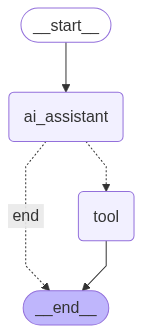

In [50]:
graph.compile()